# Xenium and scRNA-seq Integration with Tangram

In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import tangram as tg

In [3]:
xenium_data = sc.read_h5ad("data/gut_data/gut_hs_XeniumAdultColonNicheCompass_AM_21102024_150114_raw.h5ad")

In [4]:
scrna_data = sc.read_h5ad("data/gut_data/Healthy_colon_adult.h5ad")

In [5]:
sc.pp.filter_genes(scrna_data, min_cells=3)

In [6]:
common_genes = np.intersect1d(xenium_data.var_names, scrna_data.var_names)

In [7]:
tg.pp_adatas(scrna_data, xenium_data, genes=common_genes)

INFO:root:407 training genes are saved in `uns``training_genes` of both single cell and spatial Anndatas.
INFO:root:407 overlapped genes are saved in `uns``overlap_genes` of both single cell and spatial Anndatas.
INFO:root:uniform based density prior is calculated and saved in `obs``uniform_density` of the spatial Anndata.
INFO:root:rna count based density prior is calculated and saved in `obs``rna_count_based_density` of the spatial Anndata.


In [8]:
scrna_data.obs['cell_subclass'] = scrna_data.obs['Cell States']
xenium_data.obs['cell_subclass'] = xenium_data.obs['C_scANVI']

In [9]:
ad_map = tg.map_cells_to_space(scrna_data, xenium_data,
    mode="cells",
    cluster_label='cell_subclass',  # .obs field w cell types
    density_prior='rna_count_based',
    num_epochs=500,
    # device="cuda:0",
    device='cpu',
)

INFO:root:Allocate tensors for mapping.
INFO:root:Begin training with 407 genes and rna_count_based density_prior in cells mode...


: 

: 

: 

In [ ]:
ad_ge = tg.project_genes(ad_map, scrna_data)

In [ ]:
ad_map = tg.map_cells_to_space(scrna_data, xenium_data,
    mode="cells",
#     mode="clusters",
     cluster_label='cell_subclass',  # .obs field w cell types
    density_prior='rna_count_based',
    num_epochs=500,
    # device="cuda:0",
    device='cpu',
)

## Subset to common genes

In [5]:
common_genes = np.intersect1d(xenium_data.var_names, scrna_data.var_names)
print(f"Number of common genes: {len(common_genes)}")

Number of common genes: 407


In [6]:
xenium_data = xenium_data[:, common_genes].copy()
scrna_data = scrna_data[:, common_genes].copy()

## Normalize and log transform

In [7]:
sc.pp.normalize_total(scrna_data, target_sum=1e6, exclude_highly_expressed=True)
sc.pp.log1p(scrna_data)

/Users/annamaguza/Library/Application Support/hatch/env/virtual/single-cell-project/0fJ3OPid/single_cell_project/lib/python3.11/site-packages/scanpy/preprocessing/_normalization.py:235: UserWarning: Some cells have zero counts
  warn(UserWarning("Some cells have zero counts"))


In [8]:
sc.pp.normalize_total(xenium_data)
sc.pp.log1p(xenium_data)

In [ ]:
xenium_data.obs['dataset'] = 'xenium'
scrna_data.obs['dataset'] = 'scrna'

+ Check if datasets in the common scale

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
/var/folders/kr/nd4y_1_s34n42lrht8wdh4cr0000gq/T/ipykernel_19550/1658734270.py:73: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[1, 1].set_xticklabels(axs[1, 1].get_xticklabels(), rotation=45, ha='right')


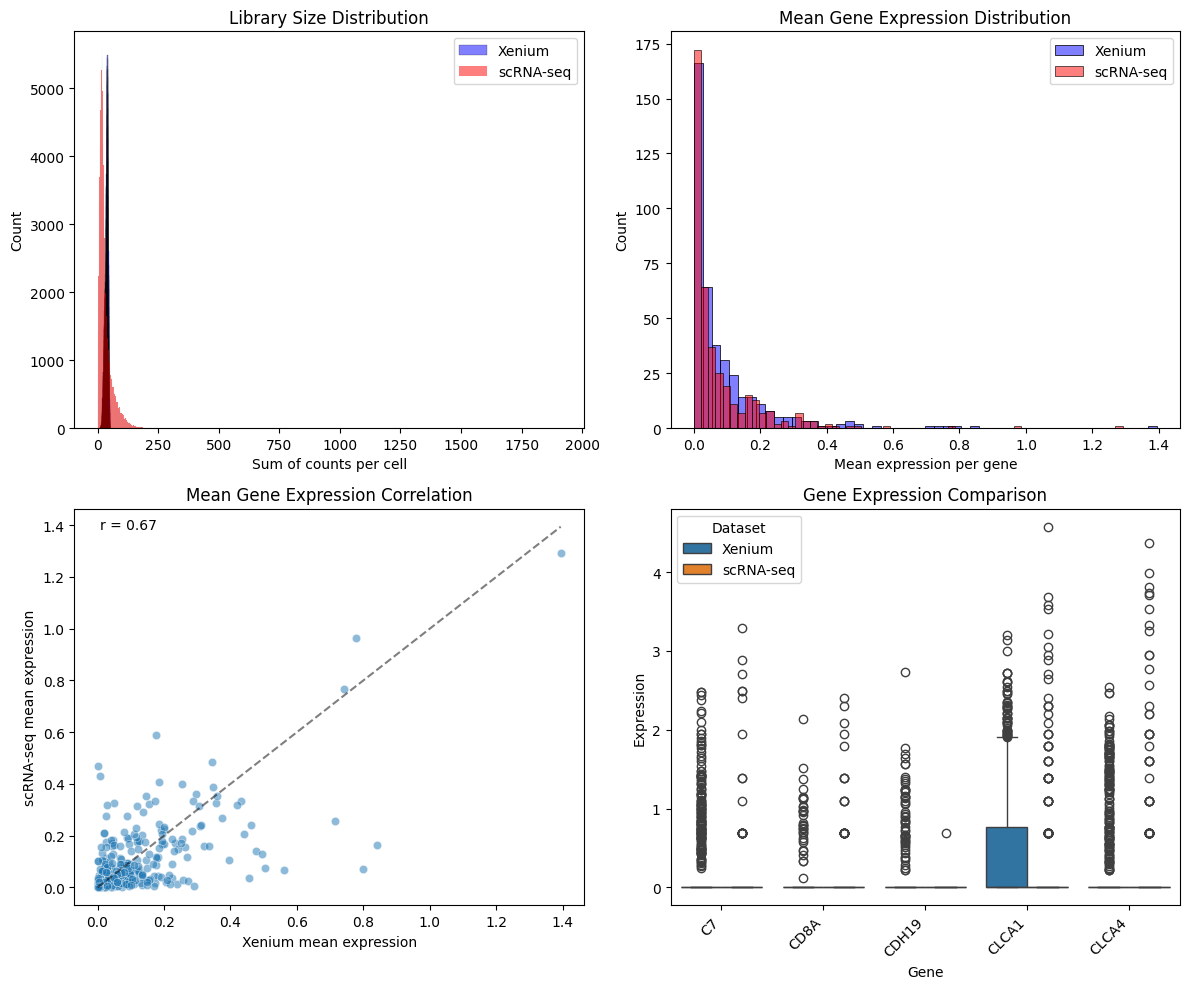

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

# 1. Library size distribution
lib_size_xenium = np.array(xenium_data.X.sum(axis=1)).flatten()
lib_size_scrna = np.array(scrna_data.X.sum(axis=1)).flatten()

sns.histplot(lib_size_xenium, color='blue', alpha=0.5, label='Xenium', ax=axs[0, 0])
sns.histplot(lib_size_scrna, color='red', alpha=0.5, label='scRNA-seq', ax=axs[0, 0])
axs[0, 0].set_title('Library Size Distribution')
axs[0, 0].set_xlabel('Sum of counts per cell')
axs[0, 0].legend()

# 2. Compare gene expression distributions 
gene_means_xenium = np.array(xenium_data[:, common_genes].X.mean(axis=0)).flatten()
gene_means_scrna = np.array(scrna_data[:, common_genes].X.mean(axis=0)).flatten()

sns.histplot(gene_means_xenium, color='blue', alpha=0.5, label='Xenium', ax=axs[0, 1])
sns.histplot(gene_means_scrna, color='red', alpha=0.5, label='scRNA-seq', ax=axs[0, 1])
axs[0, 1].set_title('Mean Gene Expression Distribution')
axs[0, 1].set_xlabel('Mean expression per gene')
axs[0, 1].legend()

# 3. Scatterplot of mean gene expression (Xenium vs scRNA-seq)
mean_exp_df = pd.DataFrame({
    'Xenium': gene_means_xenium,
    'scRNA-seq': gene_means_scrna
})

sns.scatterplot(x='Xenium', y='scRNA-seq', data=mean_exp_df, ax=axs[1, 0], alpha=0.5)
axs[1, 0].set_title('Mean Gene Expression Correlation')
axs[1, 0].set_xlabel('Xenium mean expression')
axs[1, 0].set_ylabel('scRNA-seq mean expression')

# Add correlation line
slope, intercept, r_value, p_value, std_err = stats.linregress(gene_means_xenium, gene_means_scrna)
axs[1, 0].text(0.05, 0.95, f'r = {r_value:.2f}', transform=axs[1, 0].transAxes)

# Add 1:1 line for reference
max_val = max(gene_means_xenium.max(), gene_means_scrna.max())
axs[1, 0].plot([0, max_val], [0, max_val], 'k--', alpha=0.5)

# 4. Box plots of selected highly variable genes
# Select a few highly variable genes for comparison
sc.pp.highly_variable_genes(xenium_data, n_top_genes=50, flavor='seurat')
sc.pp.highly_variable_genes(scrna_data, n_top_genes=50, flavor='seurat')

hvg_xenium = xenium_data.var_names[xenium_data.var.highly_variable]
hvg_scrna = scrna_data.var_names[scrna_data.var.highly_variable]
common_hvgs = hvg_xenium.intersection(hvg_scrna)

# Select top 5 common HVGs (or fewer if not enough)
selected_genes = list(common_hvgs)[:min(5, len(common_hvgs))]

# Create a dataframe for plotting
box_data = []
for gene in selected_genes:
    # Sample a subset of cells for faster plotting if needed
    xenium_expr = xenium_data[:, gene].X.toarray().flatten() if sparse.issparse(xenium_data.X) else xenium_data[:, gene].X.flatten()
    scrna_expr = scrna_data[:, gene].X.toarray().flatten() if sparse.issparse(scrna_data.X) else scrna_data[:, gene].X.flatten()
    
    # Sample if too many cells
    if len(xenium_expr) > 1000:
        xenium_expr = np.random.choice(xenium_expr, 1000, replace=False)
    if len(scrna_expr) > 1000:
        scrna_expr = np.random.choice(scrna_expr, 1000, replace=False)
    
    box_data.extend([{'Gene': gene, 'Expression': value, 'Dataset': 'Xenium'} for value in xenium_expr])
    box_data.extend([{'Gene': gene, 'Expression': value, 'Dataset': 'scRNA-seq'} for value in scrna_expr])

box_df = pd.DataFrame(box_data)
sns.boxplot(x='Gene', y='Expression', hue='Dataset', data=box_df, ax=axs[1, 1])
axs[1, 1].set_title('Gene Expression Comparison')
axs[1, 1].set_xticklabels(axs[1, 1].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig('figures/datasets_scale_comparison.png', dpi=300)
plt.show()